In [ ]:
!mkdir ~p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘~p’: File exists
mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o /content/cat-and-dog.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/training_set/training_set/cats/cat.3704.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3705.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3706.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3707.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3708.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3709.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.371.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3710.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3711.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3712.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3713.jpg  
  inflating: /content/dataset/training_set/training_set/cats/cat.3714.jpg  
  inflating: /content/dataset/training

In [ ]:
import os
for dirpath, dirnames, filenames in os.walk('/content/dataset'):
    print(dirpath, "→", len(filenames), "files")

/content/dataset → 0 files
/content/dataset/training_set → 0 files
/content/dataset/training_set/training_set → 0 files
/content/dataset/training_set/training_set/dogs → 4006 files
/content/dataset/training_set/training_set/cats → 4001 files
/content/dataset/test_set → 0 files
/content/dataset/test_set/test_set → 0 files
/content/dataset/test_set/test_set/dogs → 1013 files
/content/dataset/test_set/test_set/cats → 1012 files


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Only rescale, no augmentation
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/training_set/training_set',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    '/content/dataset/test_set/test_set',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("✅ Classes:", train_data.class_indices)
print("✅ Train samples:", train_data.samples)
print("✅ Test samples:", test_data.samples)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
✅ Classes: {'cats': 0, 'dogs': 1}
✅ Train samples: 8005
✅ Test samples: 2023


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Fully Connected Layers
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')  # binary output (cat or dog)
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.5641 - loss: 0.6779 - val_accuracy: 0.6273 - val_loss: 0.6359
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.6551 - loss: 0.6203 - val_accuracy: 0.6693 - val_loss: 0.5968
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.7063 - loss: 0.5655 - val_accuracy: 0.7331 - val_loss: 0.5231
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.7522 - loss: 0.5086 - val_accuracy: 0.7731 - val_loss: 0.4827
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.7834 - loss: 0.4576 - val_accuracy: 0.8052 - val_loss: 0.4359
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8061 - loss: 0.4263 - val_accuracy: 0.8052 - val_loss: 0.4315
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8236 - loss: 0.3850 - val_accuracy: 0.8245 - val_loss: 0.3984
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - accuracy: 0.8413 - loss: 0.3543 - 

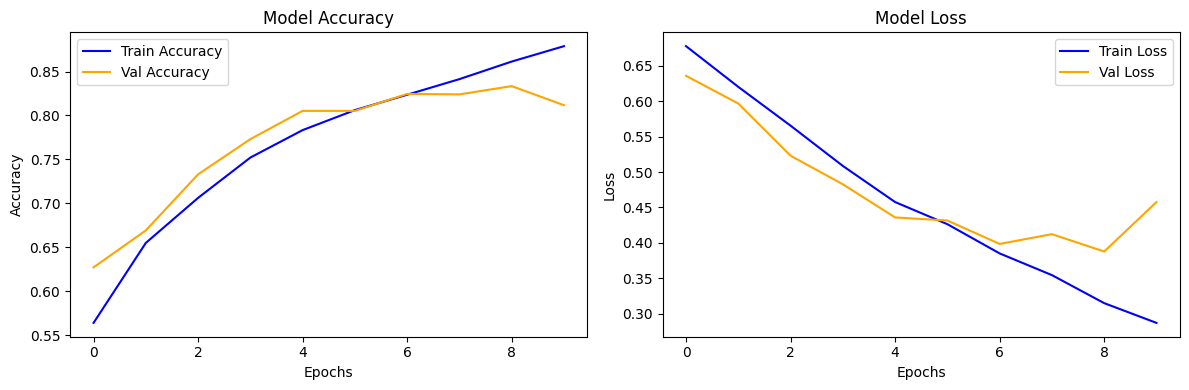

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

📤 Upload an image...


Saving WhatsApp Image 2026-05-01 at 10.14.57 PM.jpeg to WhatsApp Image 2026-05-01 at 10.14.57 PM.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
 It's a DOG! (99.97% confident)


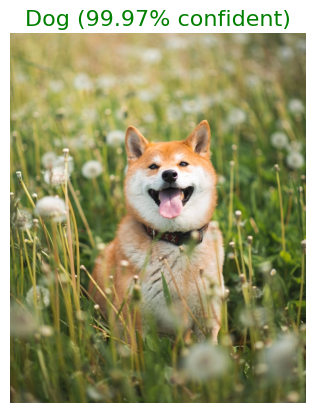

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# Upload image
print("📤 Upload an image...")
uploaded = files.upload()

# Get the uploaded file name
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
confidence = prediction[0][0]

# Show image
plt.imshow(image.load_img(img_path))
plt.axis('off')

# ✅ Confidence Threshold Logic
if confidence > 0.80:
    plt.title(f"Dog ({confidence*100:.2f}% confident)", fontsize=16, color='green')
    print(f" It's a DOG! ({confidence*100:.2f}% confident)")

elif confidence < 0.20:
    plt.title(f" Cat ({(1-confidence)*100:.2f}% confident)", fontsize=16, color='blue')
    print(f" It's a CAT! ({(1-confidence)*100:.2f}% confident)")

else:
    plt.title(f" Neither Cat nor Dog!", fontsize=16, color='red')
    print(f" This is NEITHER a Cat nor a Dog!")

plt.show()